In [1]:
!git clone --recursive https://github.com/bemc22/ModuloUnrolled
%cd ModuloUnrolled
!pip install deepinv
!pip install torch_dct

Cloning into 'ModuloUnrolled'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 50 (delta 20), reused 23 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 4.49 MiB | 11.11 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/ModuloUnrolled
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.2 MB/s eta 0:00:00


In [2]:
import os
import torch
import numpy as np
import deepinv as dinv
import cv2


from libs.unet import UNetRes as net
from libs.pnp import Unrolled, deep_denoiser
from libs.utils import unlimited
from config import model_config, MODEL_SIZE
from train_unrolled import DEVICE
from libs.utils import ToneMapping

Using cuda device


In [3]:
ITERS = 3
GAMMA = 1.01
EPSILON = 1e-5

def normalize(x):
    x -= torch.min( torch.min(x, dim=-1, keepdim=True)[0] ,dim=-2, keepdim=True)[0]
    x /= torch.max( torch.max(x, dim=-1, keepdim=True)[0] ,dim=-2, keepdim=True)[0]
    return x


size = 512
n_channels = 3
dynamic_range = 4  # dynamic range
threshold = 1.0  # threshold for spatial unwrapping
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
img_size = (size, size)

cuda


In [4]:
x_rgb = np.load("example.npy")
# resize
x_rgb = cv2.resize(x_rgb, img_size)

x_rgb = torch.from_numpy(x_rgb).unsqueeze(0).to(device)
x_rgb = x_rgb.permute(0, 3, 1, 2)

x_rgb = normalize(x_rgb) * dynamic_range

modulo_image = unlimited(x_rgb, 1.0)

In [5]:
model_config["in_nc"]  = n_channels * 2 + 1
model_config["out_nc"] = n_channels

model_unrolled = Unrolled(
        net(**model_config), deep_denoiser, max_iters=ITERS, gamma=GAMMA, epsilon=EPSILON
)

model_name = f"unrolled_{MODEL_SIZE}"
model_pool = "ckpts"
model_path = os.path.join(".", model_pool, model_name + ".pth")
model_unrolled.load_state_dict(torch.load(model_path), strict=True)
model_unrolled = model_unrolled.to(DEVICE)


psnr_fn = dinv.loss.metric.PSNR(max_pixel=dynamic_range)
ssim_fn = dinv.loss.metric.SSIM(max_pixel=dynamic_range)

In [6]:
with torch.no_grad():
    x_rec = model_unrolled(modulo_image, std=0.0)
    psnr = psnr_fn(x_rec, x_rgb).item()
    ssim = ssim_fn(x_rec, x_rgb).item()
    print(f"PSNR: {psnr:.2f} dB, SSIM: {ssim:.4f}")

PSNR: 21.79 dB, SSIM: 0.8791


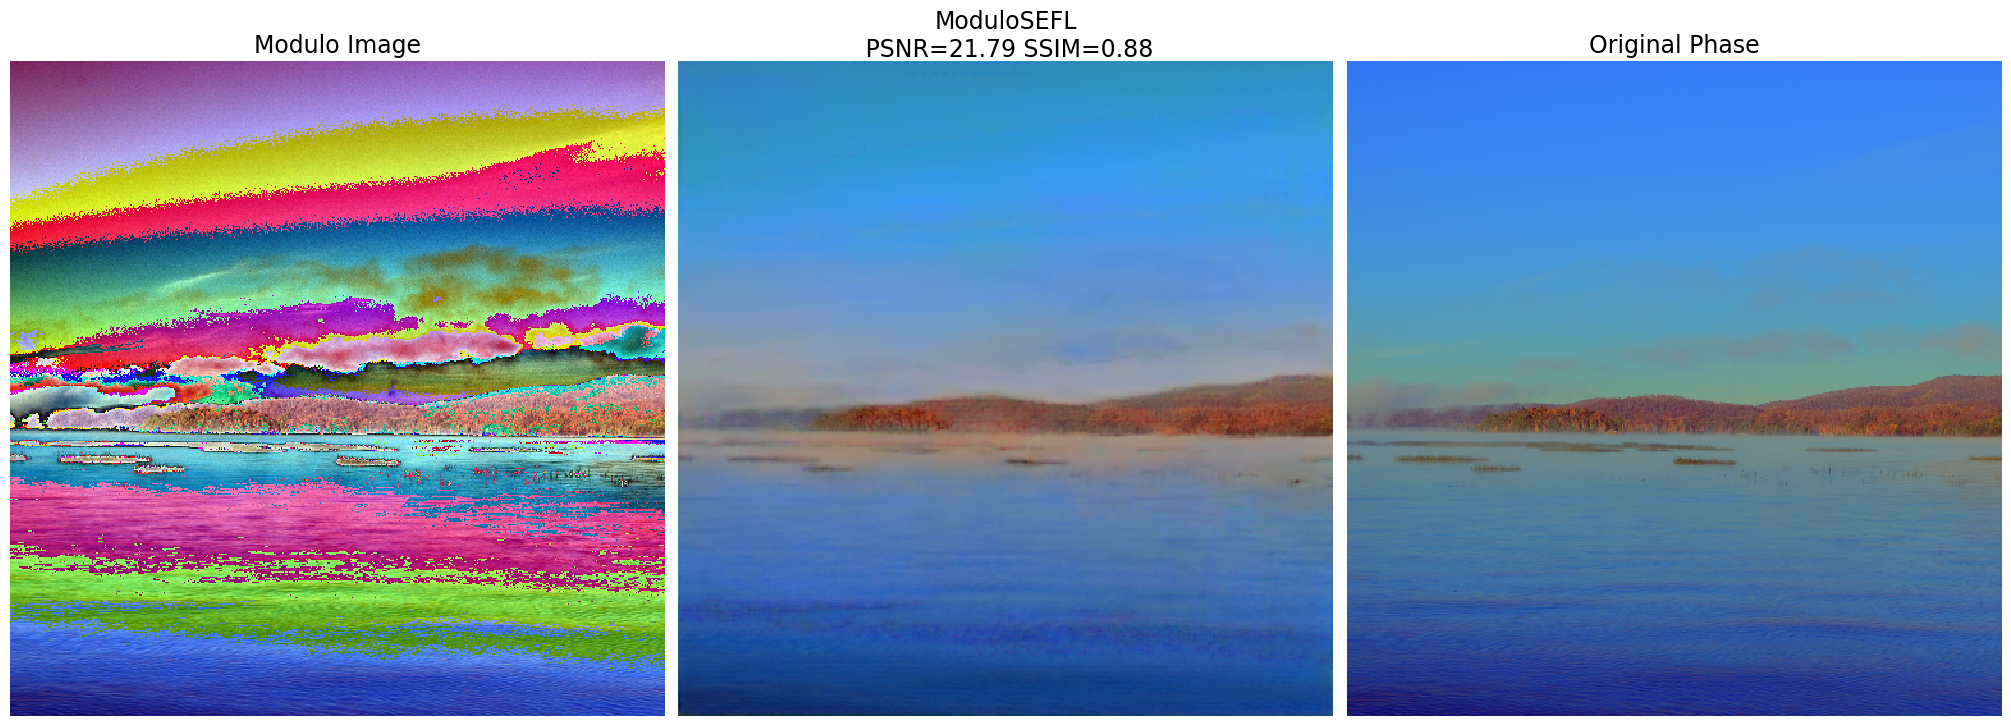

In [7]:

# Plot results
tone_map = ToneMapping(factor=0.6)
x_rec_plot = tone_map(x_rec)
x_rgb_plot = tone_map(x_rgb)

x_rec_plot /= x_rec_plot.max()
x_rgb_plot /= x_rgb_plot.max()



imgs = [modulo_image[0],  x_rec_plot[0], x_rgb_plot[0]]
titles = [
    "Modulo Image",
    f"ModuloSEFL\n PSNR={psnr:.2f} SSIM={ssim:.2f}",
    "Original Phase",
]

dinv.utils.plotting.plot(imgs, titles=titles, cmap="gray", figsize=(20, 10))